
# Paso 06 · Entrenamiento y comparación de modelos

Este notebook compara los cinco modelos definidos para el proyecto:

1. Regresión Logística
2. Random Forest
3. XGBoost
4. SVM con kernel RBF
5. MLP

El objetivo continúa siendo:

\[
X_{z,t}\rightarrow Y_{z,t+1}
\]

con `target_amenaza ∈ {Baja, Media, Alta}`.

## Reglas metodológicas

- Solo se utiliza `split == entrenamiento` (1991–2017, zonas de desarrollo).
- **No se consulta validación temporal 2018–2021.**
- **No se consulta prueba temporal 2022–2025.**
- **No se consulta el holdout espacial.**
- Las características permitidas se leen desde `catalogo_caracteristicas_modelado.csv`.
- La selección supervisada de características ocurre **dentro de cada fold temporal** mediante `SelectKBest`.
- El preprocesamiento también ocurre dentro del `Pipeline`.
- La métrica principal para escoger configuración y modelo es **Macro F1**.
- También se reportan Balanced Accuracy, Recall de `Alta` y F1 por clase.

Esto evita que la selección de características vea datos futuros y, por tanto, evita leakage.


In [1]:

from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    recall_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "Falta xgboost. Instálalo con: py -m pip install xgboost"
    ) from exc

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
CLASS_ORDER = ["Baja", "Media", "Alta"]

BASE_DIR = Path.cwd()
while not (BASE_DIR / "zonas_era5_ecuador.csv").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent
if not (BASE_DIR / "zonas_era5_ecuador.csv").exists():
    raise FileNotFoundError("No se pudo localizar la raiz del proyecto.")

DATA_FILE = (
    BASE_DIR
    / "datos"
    / "modelado"
    / "dataset_caracteristicas_candidatas.csv"
)

CATALOG_FILE = (
    BASE_DIR
    / "resultados"
    / "analisis_caracteristicas"
    / "catalogo_caracteristicas_modelado.csv"
)

OUTPUT_DIR = (
    BASE_DIR
    / "resultados"
    / "modelos_cv"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# False = búsqueda oficial.
# True = prueba rápida para verificar que todo el notebook corre.
MODO_RAPIDO = False

print(f"Dataset: {DATA_FILE}")
print(f"Catálogo: {CATALOG_FILE}")
print(f"Resultados: {OUTPUT_DIR}")
print(f"Modo rápido: {MODO_RAPIDO}")


Dataset: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\datos\modelado\dataset_caracteristicas_candidatas.csv
Catálogo: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\resultados\analisis_caracteristicas\catalogo_caracteristicas_modelado.csv
Resultados: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\resultados\modelos_cv
Modo rápido: False



## 1. Cargar dataset y catálogo oficial de predictors

El dataset contiene metadatos y targets además de las features. Por eso **NO** usamos `df.drop(...)`.

La lista de predictors sale exclusivamente del catálogo generado en el Paso 05. Esta es nuestra barrera explícita contra leakage.


In [2]:

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"No se encontró {DATA_FILE}. Ejecuta primero el Paso 05."
    )

if not CATALOG_FILE.exists():
    raise FileNotFoundError(
        f"No se encontró {CATALOG_FILE}. Ejecuta primero el Paso 05."
    )

df = pd.read_csv(DATA_FILE, encoding="utf-8-sig")
catalog = pd.read_csv(CATALOG_FILE, encoding="utf-8-sig")

df["period_start"] = pd.to_datetime(df["period_start"])
df["target_period_start"] = pd.to_datetime(df["target_period_start"])

FEATURES = catalog["caracteristica"].tolist()

NUMERIC_FEATURES = catalog.loc[
    catalog["tipo"] == "numerica",
    "caracteristica",
].tolist()

CATEGORICAL_FEATURES = catalog.loc[
    catalog["tipo"] == "categorica",
    "caracteristica",
].tolist()

missing = sorted(set(FEATURES).difference(df.columns))

if missing:
    raise ValueError(
        f"El catálogo contiene features ausentes del dataset: {missing}"
    )

FORBIDDEN = {
    "target_amenaza",
    "target_rx5day_mm",
    "target_period_start",
    "amenaza_mes",
    "split",
    "rol",
    "zone_id",
    "ciudad",
    "provincia",
    "period",
    "period_start",
}

leakage = sorted(set(FEATURES).intersection(FORBIDDEN))

if leakage:
    raise RuntimeError(
        f"LEAKAGE: el catálogo contiene columnas prohibidas: {leakage}"
    )

train = (
    df[df["split"] == "entrenamiento"]
    .sort_values(["target_period_start", "zone_id"])
    .reset_index(drop=True)
    .copy()
)

print(f"Dataset completo: {len(df):,} filas")
print(f"Entrenamiento Paso 06: {len(train):,} filas")
print(f"Predictors numéricos: {len(NUMERIC_FEATURES)}")
print(f"Predictors categóricos: {len(CATEGORICAL_FEATURES)}")
print(f"Total candidatos antes de one-hot: {len(FEATURES)}")

print("\nDistribución del target en entrenamiento:")
print(
    train["target_amenaza"]
    .value_counts()
    .reindex(CLASS_ORDER)
)


Dataset completo: 6,120 filas
Entrenamiento Paso 06: 3,744 filas
Predictors numéricos: 37
Predictors categóricos: 1
Total candidatos antes de one-hot: 38

Distribución del target en entrenamiento:
target_amenaza
Baja     1234
Media    1231
Alta     1279
Name: count, dtype: int64



## 2. Codificar el target

Usamos una codificación fija para que todos los clasificadores, incluido XGBoost, reciban exactamente el mismo objetivo:

- Baja = 0
- Media = 1
- Alta = 2


In [3]:

TARGET_TO_INT = {
    "Baja": 0,
    "Media": 1,
    "Alta": 2,
}

INT_TO_TARGET = {
    value: key
    for key, value in TARGET_TO_INT.items()
}

X_train = train[FEATURES].copy()
y_train = train["target_amenaza"].map(TARGET_TO_INT).astype(int)

if y_train.isna().any():
    raise ValueError("El target contiene clases no reconocidas.")

print(TARGET_TO_INT)


{'Baja': 0, 'Media': 1, 'Alta': 2}



## 3. Validación cruzada temporal expansiva

No utilizamos `KFold` aleatorio.

Cada fold entrena exclusivamente con años anteriores y valida en un bloque futuro:

| Fold | Entrenamiento | Validación |
|---|---|---|
| 1 | hasta 2004 | 2005–2007 |
| 2 | hasta 2007 | 2008–2010 |
| 3 | hasta 2010 | 2011–2013 |
| 4 | hasta 2013 | 2014–2017 |

Los cortes se hacen respecto a `target_period_start`, porque ese es el mes que se está prediciendo.


In [4]:

FOLD_DEFINITIONS = [
    {
        "fold": 1,
        "train_end": "2004-12-01",
        "val_start": "2005-01-01",
        "val_end": "2007-12-01",
    },
    {
        "fold": 2,
        "train_end": "2007-12-01",
        "val_start": "2008-01-01",
        "val_end": "2010-12-01",
    },
    {
        "fold": 3,
        "train_end": "2010-12-01",
        "val_start": "2011-01-01",
        "val_end": "2013-12-01",
    },
    {
        "fold": 4,
        "train_end": "2013-12-01",
        "val_start": "2014-01-01",
        "val_end": "2017-12-01",
    },
]

cv_splits = []
fold_rows = []

dates = train["target_period_start"]

for spec in FOLD_DEFINITIONS:
    train_end = pd.Timestamp(spec["train_end"])
    val_start = pd.Timestamp(spec["val_start"])
    val_end = pd.Timestamp(spec["val_end"])

    train_idx = np.flatnonzero(
        dates <= train_end
    )

    val_idx = np.flatnonzero(
        (dates >= val_start)
        & (dates <= val_end)
    )

    if len(train_idx) == 0 or len(val_idx) == 0:
        raise ValueError(
            f"Fold {spec['fold']} quedó vacío."
        )

    max_train_date = dates.iloc[train_idx].max()
    min_val_date = dates.iloc[val_idx].min()

    if not max_train_date < min_val_date:
        raise RuntimeError(
            f"Leakage temporal en fold {spec['fold']}."
        )

    cv_splits.append(
        (train_idx, val_idx)
    )

    fold_rows.append({
        "fold": spec["fold"],
        "train_inicio": dates.iloc[train_idx].min(),
        "train_fin": max_train_date,
        "val_inicio": min_val_date,
        "val_fin": dates.iloc[val_idx].max(),
        "filas_train": len(train_idx),
        "filas_validacion": len(val_idx),
    })

fold_report = pd.DataFrame(fold_rows)

fold_report.to_csv(
    OUTPUT_DIR / "folds_temporales.csv",
    index=False,
    encoding="utf-8-sig",
)

fold_report


,fold,train_inicio,train_fin,val_inicio,val_fin,filas_train,filas_validacion
0,1,1992-01-01,2004-12-01,2005-01-01,2007-12-01,1872,432
1,2,1992-01-01,2007-12-01,2008-01-01,2010-12-01,2304,432
2,3,1992-01-01,2010-12-01,2011-01-01,2013-12-01,2736,432
3,4,1992-01-01,2013-12-01,2014-01-01,2017-12-01,3168,576



## 4. Baselines

Antes de celebrar cualquier F1, comparamos contra tres referencias:

### Dummy
Predice siempre la clase mayoritaria del fold de entrenamiento.

### Persistencia
Predice que el siguiente mes tendrá la misma clase que el mes actual.

\[
\hat Y_{t+1}=Y_t
\]

`amenaza_mes` se usa **solo aquí**, como baseline explícito.

### Climatología mensual
Para cada mes objetivo (enero, febrero, etc.) aprende la clase más frecuente **solo en el bloque de entrenamiento del fold** y la usa para el futuro.

Este baseline es importante porque nuestro target global conserva estacionalidad. Un modelo serio debería superar una regla que simplemente conozca el mes del año.


In [5]:

def metric_row(
    y_true,
    y_pred,
    model_name,
    fold,
):
    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0, 1, 2],
            zero_division=0,
        )
    )

    return {
        "modelo": model_name,
        "fold": fold,
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision_baja": precision[0],
        "recall_baja": recall[0],
        "f1_baja": f1[0],
        "precision_media": precision[1],
        "recall_media": recall[1],
        "f1_media": f1[1],
        "precision_alta": precision[2],
        "recall_alta": recall[2],
        "f1_alta": f1[2],
    }


baseline_rows = []
baseline_oof = []

for fold_number, (tr_idx, va_idx) in enumerate(
    cv_splits,
    start=1,
):
    fold_train = train.iloc[tr_idx]
    fold_val = train.iloc[va_idx]

    y_tr = y_train.iloc[tr_idx].to_numpy()
    y_va = y_train.iloc[va_idx].to_numpy()

    # Dummy
    dummy = DummyClassifier(
        strategy="most_frequent"
    )
    dummy.fit(
        np.zeros((len(y_tr), 1)),
        y_tr,
    )
    pred_dummy = dummy.predict(
        np.zeros((len(y_va), 1))
    )

    baseline_rows.append(
        metric_row(
            y_va,
            pred_dummy,
            "Dummy_most_frequent",
            fold_number,
        )
    )

    # Persistencia
    pred_persistence = (
        fold_val["amenaza_mes"]
        .map(TARGET_TO_INT)
        .astype(int)
        .to_numpy()
    )

    baseline_rows.append(
        metric_row(
            y_va,
            pred_persistence,
            "Persistencia",
            fold_number,
        )
    )

    # Climatología por mes objetivo,
    # aprendida SOLO con el train del fold.
    climatology = (
        fold_train.assign(
            target_int=(
                fold_train["target_amenaza"]
                .map(TARGET_TO_INT)
                .astype(int)
            )
        )
        .groupby("target_month")["target_int"]
        .agg(
            lambda s: s.value_counts().idxmax()
        )
        .to_dict()
    )

    global_majority = (
        pd.Series(y_tr)
        .value_counts()
        .idxmax()
    )

    pred_climatology = (
        fold_val["target_month"]
        .map(climatology)
        .fillna(global_majority)
        .astype(int)
        .to_numpy()
    )

    baseline_rows.append(
        metric_row(
            y_va,
            pred_climatology,
            "Climatologia_mes",
            fold_number,
        )
    )

baseline_fold_metrics = pd.DataFrame(
    baseline_rows
)

baseline_summary = (
    baseline_fold_metrics
    .groupby("modelo")
    .agg(
        macro_f1_media=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        balanced_accuracy_media=(
            "balanced_accuracy",
            "mean",
        ),
        recall_alta_media=("recall_alta", "mean"),
        f1_alta_media=("f1_alta", "mean"),
        f1_media_media=("f1_media", "mean"),
        f1_baja_media=("f1_baja", "mean"),
    )
    .reset_index()
    .sort_values(
        "macro_f1_media",
        ascending=False,
    )
)

baseline_fold_metrics.to_csv(
    OUTPUT_DIR / "baselines_por_fold.csv",
    index=False,
    encoding="utf-8-sig",
)

baseline_summary.to_csv(
    OUTPUT_DIR / "baselines_resumen.csv",
    index=False,
    encoding="utf-8-sig",
)

baseline_summary


,modelo,macro_f1_media,macro_f1_std,balanced_accuracy_media,recall_alta_media,f1_alta_media,f1_media_media,f1_baja_media
2,Persistencia,0.590419,0.016185,0.590301,0.616696,0.617973,0.433227,0.720055
0,Climatologia_mes,0.458722,0.040976,0.502644,0.727649,0.595685,0.170852,0.609629
1,Dummy_most_frequent,0.149057,0.010052,0.333333,0.250000,0.105839,0.341331,0.000000



## 5. Preprocesamiento y selección dentro del Pipeline

Las 37 variables numéricas pasan por:

1. imputación mediana;
2. escalado cuando el modelo lo requiere;
3. `SelectKBest(mutual_info_classif)`.

`region` se codifica con one-hot y se conserva como contexto geográfico. No se usa `zone_id`.

La cantidad \(k\) de variables numéricas seleccionadas se trata como hiperparámetro:

\[
k \in \{10,15,20,25,\text{todas}\}
\]

Así, cada fold aprende **su propia selección**, sin mirar el futuro.


In [6]:

def mutual_information_scores(X, y):
    return mutual_info_classif(
        X,
        y,
        random_state=RANDOM_STATE,
    )


K_VALUES = (
    [15]
    if MODO_RAPIDO
    else [10, 15, 20, 25, "all"]
)


def make_onehot_encoder():
    # Compatibilidad con versiones recientes y anteriores de scikit-learn.
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def make_preprocessor(
    scale_numeric: bool,
):
    numeric_steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
    ]

    if scale_numeric:
        numeric_steps.append(
            (
                "scaler",
                StandardScaler(),
            )
        )

    numeric_steps.append(
        (
            "selector",
            SelectKBest(
                score_func=mutual_information_scores,
                k="all",
            ),
        )
    )

    numeric_pipeline = Pipeline(
        numeric_steps
    )

    categorical_pipeline = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                ),
            ),
            (
                "onehot",
                make_onehot_encoder(),
            ),
        ]
    )

    return ColumnTransformer(
        [
            (
                "num",
                numeric_pipeline,
                NUMERIC_FEATURES,
            ),
            (
                "cat",
                categorical_pipeline,
                CATEGORICAL_FEATURES,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )



## 6. Modelos e hiperparámetros

La búsqueda es deliberadamente moderada. La idea no es repetir cientos de experimentos manuales, sino comparar familias de modelos bajo el mismo protocolo.

Todos los grids incluyen `k`, por lo que la cantidad de features se aprende dentro del CV.


In [7]:

if MODO_RAPIDO:
    model_specs = {
        "Logistic_Regression": {
            "estimator": LogisticRegression(
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
            "scale": True,
            "grid": {
                "preprocess__num__selector__k": K_VALUES,
                "model__C": [1.0],
            },
        },
        "Random_Forest": {
            "estimator": RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
            "scale": False,
            "grid": {
                "preprocess__num__selector__k": K_VALUES,
                "model__max_depth": [None],
                "model__min_samples_leaf": [1],
            },
        },
        "XGBoost": {
            "estimator": XGBClassifier(
                n_estimators=200,
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=RANDOM_STATE,
                n_jobs=1,
                tree_method="hist",
            ),
            "scale": False,
            "grid": {
                "preprocess__num__selector__k": K_VALUES,
                "model__max_depth": [3],
                "model__learning_rate": [0.05],
            },
        },
        "SVM_RBF": {
            "estimator": SVC(
                kernel="rbf",
            ),
            "scale": True,
            "grid": {
                "preprocess__num__selector__k": K_VALUES,
                "model__C": [10],
                "model__gamma": ["scale"],
            },
        },
        "MLP": {
            "estimator": MLPClassifier(
                max_iter=1000,
                random_state=RANDOM_STATE,
                early_stopping=False,
            ),
            "scale": True,
            "grid": {
                "preprocess__num__selector__k": K_VALUES,
                "model__hidden_layer_sizes": [(64,)],
                "model__alpha": [1e-4],
            },
        },
    }

else:
    model_specs = {
        "Logistic_Regression": {
            "estimator": LogisticRegression(
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
            "scale": True,
            "grid": {
                "preprocess__num__selector__k": K_VALUES,
                "model__C": [0.1, 1.0, 10.0],
            },
        },

        "Random_Forest": {
            "estimator": RandomForestClassifier(
                n_estimators=400,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
            "scale": False,
            "grid": {
                "preprocess__num__selector__k": K_VALUES,
                "model__max_depth": [None, 18],
                "model__min_samples_leaf": [1, 3],
            },
        },

        "XGBoost": {
            "estimator": XGBClassifier(
                n_estimators=450,
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=RANDOM_STATE,
                n_jobs=1,
                tree_method="hist",
                subsample=0.90,
                colsample_bytree=0.90,
            ),
            "scale": False,
            "grid": {
                "preprocess__num__selector__k": K_VALUES,
                "model__max_depth": [3, 6],
                "model__learning_rate": [0.03, 0.08],
            },
        },

        "SVM_RBF": {
            "estimator": SVC(
                kernel="rbf",
            ),
            "scale": True,
            "grid": {
                "preprocess__num__selector__k": K_VALUES,
                "model__C": [1, 10, 30],
                "model__gamma": ["scale", 0.05],
            },
        },

        "MLP": {
            "estimator": MLPClassifier(
                max_iter=1000,
                random_state=RANDOM_STATE,
                early_stopping=False,
            ),
            "scale": True,
            "grid": {
                "preprocess__num__selector__k": K_VALUES,
                "model__hidden_layer_sizes": [
                    (64,),
                    (64, 32),
                ],
                "model__alpha": [
                    1e-4,
                    1e-3,
                ],
            },
        },
    }

for name, spec in model_specs.items():
    combinations = 1

    for values in spec["grid"].values():
        combinations *= len(values)

    print(
        f"{name}: {combinations} configuraciones "
        f"× {len(cv_splits)} folds"
    )


Logistic_Regression: 15 configuraciones × 4 folds
Random_Forest: 20 configuraciones × 4 folds
XGBoost: 20 configuraciones × 4 folds
SVM_RBF: 30 configuraciones × 4 folds
MLP: 20 configuraciones × 4 folds



## 7. Búsqueda temporal de hiperparámetros

`GridSearchCV` recibe nuestros folds temporales explícitos. Como el selector está dentro del Pipeline, **se vuelve a ajustar desde cero dentro de cada fold y configuración**.

La optimización usa exclusivamente:

\[
\textbf{Macro F1}
\]


In [8]:

search_rows = []
best_estimators = {}
best_params = {}

for model_name, spec in model_specs.items():
    print("\n" + "=" * 70)
    print(f"MODELO: {model_name}")
    print("=" * 70)

    preprocess = make_preprocessor(
        scale_numeric=spec["scale"]
    )

    pipeline = Pipeline(
        [
            ("preprocess", preprocess),
            ("model", spec["estimator"]),
        ]
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=spec["grid"],
        scoring="f1_macro",
        cv=cv_splits,
        refit=True,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
        verbose=1,
    )

    start = time.perf_counter()

    search.fit(
        X_train,
        y_train,
    )

    elapsed = time.perf_counter() - start

    best_estimators[model_name] = (
        search.best_estimator_
    )

    best_params[model_name] = (
        search.best_params_
    )

    search_rows.append({
        "modelo": model_name,
        "mejor_macro_f1_cv": search.best_score_,
        "tiempo_busqueda_seg": elapsed,
        "mejores_parametros": json.dumps(
            search.best_params_,
            ensure_ascii=False,
            default=str,
        ),
    })

    pd.DataFrame(
        search.cv_results_
    ).to_csv(
        OUTPUT_DIR
        / f"busqueda_{model_name}.csv",
        index=False,
        encoding="utf-8-sig",
    )

    print(
        f"Mejor Macro F1 CV: "
        f"{search.best_score_:.4f}"
    )
    print(
        f"Mejores parámetros: "
        f"{search.best_params_}"
    )
    print(
        f"Tiempo: {elapsed:.1f} s"
    )

search_summary = (
    pd.DataFrame(search_rows)
    .sort_values(
        "mejor_macro_f1_cv",
        ascending=False,
    )
)

search_summary.to_csv(
    OUTPUT_DIR / "busqueda_modelos_resumen.csv",
    index=False,
    encoding="utf-8-sig",
)

with (
    OUTPUT_DIR / "mejores_parametros.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        best_params,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

search_summary



MODELO: Logistic_Regression
Fitting 4 folds for each of 15 candidates, totalling 60 fits
Mejor Macro F1 CV: 0.6967
Mejores parámetros: {'model__C': 0.1, 'preprocess__num__selector__k': 'all'}
Tiempo: 8.2 s

MODELO: Random_Forest
Fitting 4 folds for each of 20 candidates, totalling 80 fits
Mejor Macro F1 CV: 0.7012
Mejores parámetros: {'model__max_depth': 18, 'model__min_samples_leaf': 1, 'preprocess__num__selector__k': 'all'}
Tiempo: 25.9 s

MODELO: XGBoost
Fitting 4 folds for each of 20 candidates, totalling 80 fits
Mejor Macro F1 CV: 0.7064
Mejores parámetros: {'model__learning_rate': 0.08, 'model__max_depth': 3, 'preprocess__num__selector__k': 'all'}
Tiempo: 38.1 s

MODELO: SVM_RBF
Fitting 4 folds for each of 30 candidates, totalling 120 fits
Mejor Macro F1 CV: 0.7188
Mejores parámetros: {'model__C': 1, 'model__gamma': 0.05, 'preprocess__num__selector__k': 'all'}
Tiempo: 8.8 s

MODELO: MLP
Fitting 4 folds for each of 20 candidates, totalling 80 fits
Mejor Macro F1 CV: 0.6782
Mejore

,modelo,mejor_macro_f1_cv,tiempo_busqueda_seg,mejores_parametros
3,SVM_RBF,0.718816,8.849070,"{""model__C"": 1, ""model__gamma"": 0.05, ""preproc..."
2,XGBoost,0.706399,38.098010,"{""model__learning_rate"": 0.08, ""model__max_dep..."
1,Random_Forest,0.701212,25.916026,"{""model__max_depth"": 18, ""model__min_samples_l..."
0,Logistic_Regression,0.696705,8.234942,"{""model__C"": 0.1, ""preprocess__num__selector__..."
4,MLP,0.678213,61.527176,"{""model__alpha"": 0.0001, ""model__hidden_layer_..."



## 8. Evaluación fold por fold de las mejores configuraciones

Ahora fijamos los mejores hiperparámetros encontrados para cada familia y los volvemos a evaluar fold por fold.

Esto permite reportar:

- Macro F1 promedio y desviación;
- Balanced Accuracy;
- Recall `Alta`;
- F1 de Baja, Media y Alta;
- predicciones OOF;
- matriz de confusión agregada.


In [9]:

model_fold_rows = []
oof_rows = []

for model_name, best_pipeline in best_estimators.items():
    for fold_number, (tr_idx, va_idx) in enumerate(
        cv_splits,
        start=1,
    ):
        estimator = clone(best_pipeline)

        X_tr = X_train.iloc[tr_idx]
        X_va = X_train.iloc[va_idx]
        y_tr = y_train.iloc[tr_idx]
        y_va = y_train.iloc[va_idx]

        start = time.perf_counter()

        estimator.fit(
            X_tr,
            y_tr,
        )

        pred = estimator.predict(
            X_va
        )

        elapsed = time.perf_counter() - start

        row = metric_row(
            y_va.to_numpy(),
            pred,
            model_name,
            fold_number,
        )
        row["tiempo_fit_predict_seg"] = elapsed

        model_fold_rows.append(row)

        fold_meta = train.iloc[va_idx][
            [
                "zone_id",
                "target_period_start",
            ]
        ].copy()

        fold_meta["fold"] = fold_number
        fold_meta["modelo"] = model_name
        fold_meta["y_real"] = (
            y_va.map(INT_TO_TARGET).to_numpy()
        )
        fold_meta["y_pred"] = [
            INT_TO_TARGET[int(value)]
            for value in pred
        ]

        oof_rows.append(fold_meta)

model_fold_metrics = pd.DataFrame(
    model_fold_rows
)

oof_predictions = pd.concat(
    oof_rows,
    ignore_index=True,
)

model_fold_metrics.to_csv(
    OUTPUT_DIR / "metricas_modelos_por_fold.csv",
    index=False,
    encoding="utf-8-sig",
)

oof_predictions.to_csv(
    OUTPUT_DIR / "predicciones_oof_modelos.csv",
    index=False,
    encoding="utf-8-sig",
)

model_fold_metrics.head()


,modelo,fold,macro_f1,balanced_accuracy,accuracy,precision_baja,recall_baja,f1_baja,precision_media,recall_media,f1_media,precision_alta,recall_alta,f1_alta,tiempo_fit_predict_seg
0,Logistic_Regression,1,0.696916,0.703381,0.699074,0.797468,0.845638,0.820847,0.653061,0.574850,0.611465,0.629921,0.689655,0.658436,0.252013
1,Logistic_Regression,2,0.694954,0.693167,0.694444,0.822695,0.794521,0.808362,0.559211,0.611511,0.584192,0.712230,0.673469,0.692308,0.295692
2,Logistic_Regression,3,0.712753,0.710818,0.717593,0.858156,0.775641,0.814815,0.535211,0.598425,0.565056,0.758389,0.758389,0.758389,0.356929
3,Logistic_Regression,4,0.682196,0.681114,0.696181,0.781095,0.769608,0.775309,0.473684,0.522581,0.496933,0.799020,0.751152,0.774347,0.408568
4,Random_Forest,1,0.690665,0.691404,0.692130,0.788462,0.825503,0.806557,0.621951,0.610778,0.616314,0.660714,0.637931,0.649123,2.016341



## 9. Comparación final del Paso 06

La decisión se toma por **Macro F1 medio de los folds temporales**.

`Recall Alta` se conserva como métrica crítica secundaria porque el proyecto busca no perder meses de alta intensidad.


In [10]:

model_summary = (
    model_fold_metrics
    .groupby("modelo")
    .agg(
        macro_f1_media=(
            "macro_f1",
            "mean",
        ),
        macro_f1_std=(
            "macro_f1",
            "std",
        ),
        balanced_accuracy_media=(
            "balanced_accuracy",
            "mean",
        ),
        accuracy_media=(
            "accuracy",
            "mean",
        ),
        recall_alta_media=(
            "recall_alta",
            "mean",
        ),
        f1_alta_media=(
            "f1_alta",
            "mean",
        ),
        f1_media_media=(
            "f1_media",
            "mean",
        ),
        f1_baja_media=(
            "f1_baja",
            "mean",
        ),
        tiempo_medio_fold_seg=(
            "tiempo_fit_predict_seg",
            "mean",
        ),
    )
    .reset_index()
)

all_comparison = pd.concat(
    [
        model_summary.assign(
            tipo="modelo_ml"
        ),
        baseline_summary.rename(
            columns={
                "balanced_accuracy_media":
                    "balanced_accuracy_media",
                "recall_alta_media":
                    "recall_alta_media",
            }
        ).assign(
            accuracy_media=np.nan,
            tiempo_medio_fold_seg=np.nan,
            tipo="baseline",
        ),
    ],
    ignore_index=True,
    sort=False,
)

all_comparison = all_comparison.sort_values(
    "macro_f1_media",
    ascending=False,
)

all_comparison.to_csv(
    OUTPUT_DIR / "comparacion_modelos_cv.csv",
    index=False,
    encoding="utf-8-sig",
)

all_comparison


,modelo,macro_f1_media,macro_f1_std,balanced_accuracy_media,accuracy_media,recall_alta_media,f1_alta_media,f1_media_media,f1_baja_media,tiempo_medio_fold_seg,tipo
3,SVM_RBF,0.718816,0.019305,0.718017,0.720197,0.713087,0.730448,0.607887,0.818114,0.493977,modelo_ml
4,XGBoost,0.706399,0.018427,0.705045,0.709346,0.698112,0.714484,0.591842,0.812873,1.616327,modelo_ml
2,Random_Forest,0.701212,0.017964,0.700148,0.705150,0.701743,0.710916,0.577977,0.814743,2.687647,modelo_ml
0,Logistic_Regression,0.696705,0.012532,0.697120,0.701823,0.718166,0.720870,0.564411,0.804833,0.328300,modelo_ml
1,MLP,0.678213,0.022594,0.679316,0.685041,0.685032,0.684512,0.542316,0.807809,2.226513,modelo_ml
5,Persistencia,0.590419,0.016185,0.590301,NaN,0.616696,0.617973,0.433227,0.720055,NaN,baseline
6,Climatologia_mes,0.458722,0.040976,0.502644,NaN,0.727649,0.595685,0.170852,0.609629,NaN,baseline
7,Dummy_most_frequent,0.149057,0.010052,0.333333,NaN,0.250000,0.105839,0.341331,0.000000,NaN,baseline


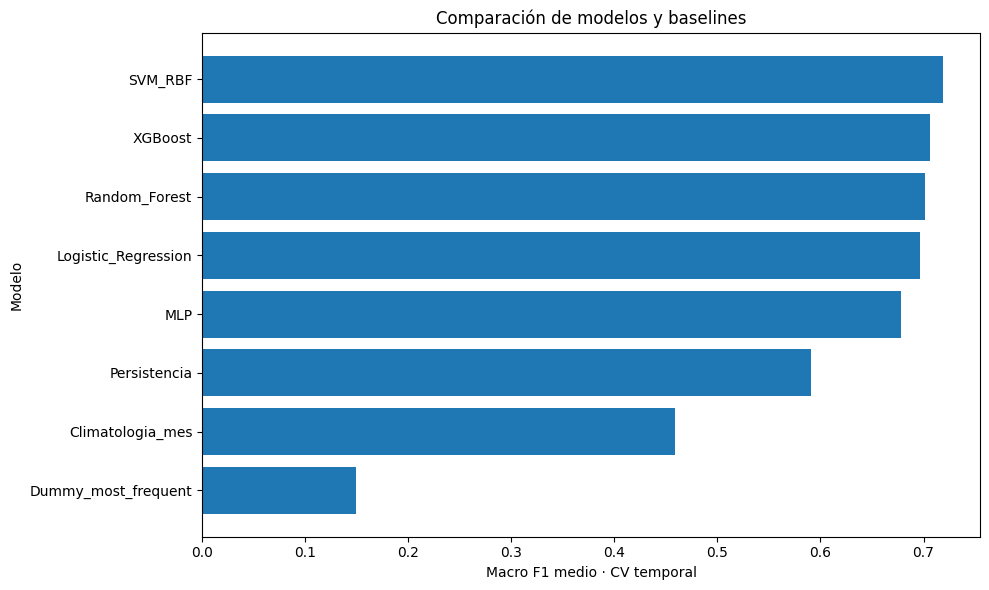

In [11]:

plt.figure(figsize=(10, 6))

plot_df = all_comparison.sort_values(
    "macro_f1_media",
    ascending=True,
)

plt.barh(
    plot_df["modelo"],
    plot_df["macro_f1_media"],
)

plt.xlabel("Macro F1 medio · CV temporal")
plt.ylabel("Modelo")
plt.title("Comparación de modelos y baselines")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_comparacion_macro_f1_cv.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()


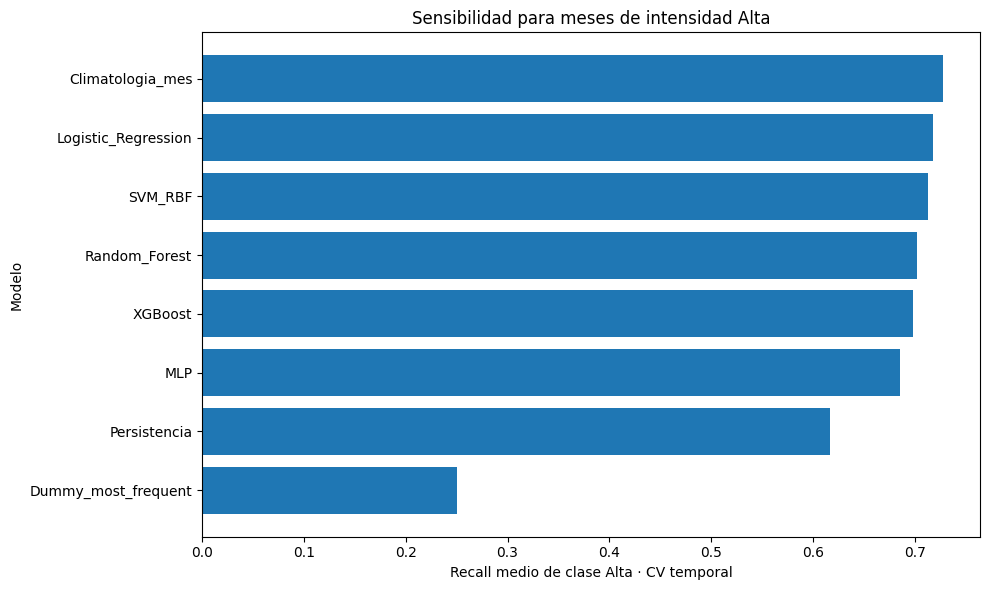

In [12]:

plt.figure(figsize=(10, 6))

plot_df = all_comparison.sort_values(
    "recall_alta_media",
    ascending=True,
)

plt.barh(
    plot_df["modelo"],
    plot_df["recall_alta_media"],
)

plt.xlabel("Recall medio de clase Alta · CV temporal")
plt.ylabel("Modelo")
plt.title("Sensibilidad para meses de intensidad Alta")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_comparacion_recall_alta_cv.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()



## 10. Matrices de confusión OOF

Las predicciones OOF reúnen únicamente meses que fueron validados como futuro dentro de cada fold.


In [13]:

for model_name in best_estimators:
    subset = oof_predictions[
        oof_predictions["modelo"]
        == model_name
    ]

    y_true_names = subset["y_real"]
    y_pred_names = subset["y_pred"]

    cm = confusion_matrix(
        y_true_names,
        y_pred_names,
        labels=CLASS_ORDER,
    )

    cm_df = pd.DataFrame(
        cm,
        index=[
            f"real_{name}"
            for name in CLASS_ORDER
        ],
        columns=[
            f"pred_{name}"
            for name in CLASS_ORDER
        ],
    )

    cm_df.to_csv(
        OUTPUT_DIR
        / f"matriz_confusion_oof_{model_name}.csv",
        encoding="utf-8-sig",
    )

    print(f"\n{model_name}")
    display(cm_df)



Logistic_Regression


,pred_Baja,pred_Media,pred_Alta
real_Baja,520,115,20
real_Media,106,338,144
real_Alta,15,159,455



Random_Forest


,pred_Baja,pred_Media,pred_Alta
real_Baja,520,116,19
real_Media,87,355,146
real_Alta,15,167,447



XGBoost


,pred_Baja,pred_Media,pred_Alta
real_Baja,515,118,22
real_Media,85,370,133
real_Alta,12,173,444



SVM_RBF


,pred_Baja,pred_Media,pred_Alta
real_Baja,516,122,17
real_Media,79,381,128
real_Alta,13,164,452



MLP


,pred_Baja,pred_Media,pred_Alta
real_Baja,526,105,24
real_Media,100,321,167
real_Alta,23,170,436



## 11. ¿Qué características eligió cada modelo?

La frecuencia se calcula reentrenando la mejor configuración dentro de cada fold.

Una feature seleccionada 4/4 veces es mucho más estable que una que aparece solamente en un fold.

`region` no pasa por `SelectKBest`; sus dummies se mantienen siempre como contexto geográfico.


In [14]:

selection_rows = []

for model_name, best_pipeline in best_estimators.items():
    for fold_number, (tr_idx, va_idx) in enumerate(
        cv_splits,
        start=1,
    ):
        estimator = clone(
            best_pipeline
        )

        estimator.fit(
            X_train.iloc[tr_idx],
            y_train.iloc[tr_idx],
        )

        preprocess = (
            estimator
            .named_steps["preprocess"]
        )

        numeric_pipe = (
            preprocess
            .named_transformers_["num"]
        )

        selector = (
            numeric_pipe
            .named_steps["selector"]
        )

        support = (
            selector.get_support()
        )

        selected_numeric = [
            feature
            for feature, selected
            in zip(
                NUMERIC_FEATURES,
                support,
            )
            if selected
        ]

        for feature in selected_numeric:
            selection_rows.append({
                "modelo": model_name,
                "fold": fold_number,
                "caracteristica": feature,
                "tipo_seleccion": (
                    "SelectKBest_MI"
                ),
            })

        cat_transformer = (
            preprocess
            .named_transformers_["cat"]
        )

        onehot = (
            cat_transformer
            .named_steps["onehot"]
        )

        category_names = (
            onehot.get_feature_names_out(
                CATEGORICAL_FEATURES
            )
        )

        for feature in category_names:
            selection_rows.append({
                "modelo": model_name,
                "fold": fold_number,
                "caracteristica": feature,
                "tipo_seleccion": (
                    "contexto_categorico_siempre"
                ),
            })

selection_detail = pd.DataFrame(
    selection_rows
)

selection_frequency = (
    selection_detail
    .groupby(
        [
            "modelo",
            "caracteristica",
            "tipo_seleccion",
        ]
    )
    .size()
    .rename("folds_seleccionada")
    .reset_index()
)

selection_frequency[
    "porcentaje_folds"
] = (
    100
    * selection_frequency[
        "folds_seleccionada"
    ]
    / len(cv_splits)
)

selection_detail.to_csv(
    OUTPUT_DIR
    / "caracteristicas_seleccionadas_por_fold.csv",
    index=False,
    encoding="utf-8-sig",
)

selection_frequency.to_csv(
    OUTPUT_DIR
    / "frecuencia_caracteristicas_seleccionadas.csv",
    index=False,
    encoding="utf-8-sig",
)

selection_frequency.sort_values(
    [
        "modelo",
        "folds_seleccionada",
    ],
    ascending=[True, False],
).head(50)


,modelo,caracteristica,tipo_seleccion,folds_seleccionada,porcentaje_folds
0,Logistic_Regression,cdd_days,SelectKBest_MI,4,100.0
1,Logistic_Regression,cdd_days__lag1,SelectKBest_MI,4,100.0
2,Logistic_Regression,cdd_days__lag11,SelectKBest_MI,4,100.0
3,Logistic_Regression,cwd_days,SelectKBest_MI,4,100.0
4,Logistic_Regression,cwd_days__lag1,SelectKBest_MI,4,100.0
5,Logistic_Regression,cwd_days__lag11,SelectKBest_MI,4,100.0
6,Logistic_Regression,latitud_solicitada,SelectKBest_MI,4,100.0
7,Logistic_Regression,longitud_solicitada,SelectKBest_MI,4,100.0
8,Logistic_Regression,max_3h_mm,SelectKBest_MI,4,100.0
9,Logistic_Regression,max_3h_mm__lag1,SelectKBest_MI,4,100.0



## 12. Resultado del Paso 06

El ganador de esta etapa es el modelo con mayor Macro F1 medio en validación cruzada temporal.

**Todavía NO es el resultado final del proyecto.**

En el Paso 07:

1. se fijará su configuración;
2. se entrenará con todo el bloque de entrenamiento 1991–2017;
3. recién entonces se evaluará una sola vez en `validacion_temporal` 2018–2021.

El test 2022–2025 y el holdout espacial continuarán intactos.


In [15]:

ml_only = all_comparison[
    all_comparison["tipo"]
    == "modelo_ml"
].sort_values(
    "macro_f1_media",
    ascending=False,
)

winner = ml_only.iloc[0]

best_baseline = (
    all_comparison[
        all_comparison["tipo"]
        == "baseline"
    ]
    .sort_values(
        "macro_f1_media",
        ascending=False,
    )
    .iloc[0]
)

print("GANADOR ML DEL PASO 06")
print("-----------------------")
print(
    f"Modelo: {winner['modelo']}"
)
print(
    f"Macro F1 CV: "
    f"{winner['macro_f1_media']:.4f} "
    f"± {winner['macro_f1_std']:.4f}"
)
print(
    f"Balanced Accuracy: "
    f"{winner['balanced_accuracy_media']:.4f}"
)
print(
    f"Recall Alta: "
    f"{winner['recall_alta_media']:.4f}"
)
print(
    f"F1 Baja / Media / Alta: "
    f"{winner['f1_baja_media']:.4f} / "
    f"{winner['f1_media_media']:.4f} / "
    f"{winner['f1_alta_media']:.4f}"
)

print("\nMEJOR BASELINE")
print("-------------")
print(
    f"{best_baseline['modelo']}: "
    f"Macro F1 = "
    f"{best_baseline['macro_f1_media']:.4f}"
)

improvement = (
    winner["macro_f1_media"]
    - best_baseline["macro_f1_media"]
)

print(
    f"\nMejora absoluta sobre mejor baseline: "
    f"{improvement:+.4f}"
)

winner_payload = {
    "modelo_ganador": winner["modelo"],
    "macro_f1_cv_media": float(
        winner["macro_f1_media"]
    ),
    "macro_f1_cv_std": float(
        winner["macro_f1_std"]
    ),
    "balanced_accuracy_media": float(
        winner["balanced_accuracy_media"]
    ),
    "recall_alta_media": float(
        winner["recall_alta_media"]
    ),
    "mejores_parametros": best_params[
        winner["modelo"]
    ],
    "mejor_baseline": (
        best_baseline["modelo"]
    ),
    "macro_f1_mejor_baseline": float(
        best_baseline["macro_f1_media"]
    ),
}

with (
    OUTPUT_DIR
    / "ganador_paso06.json"
).open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        winner_payload,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

print(
    "\nPaso 06 completado sin consultar "
    "validación 2018–2021, test ni holdout."
)


GANADOR ML DEL PASO 06
-----------------------
Modelo: SVM_RBF
Macro F1 CV: 0.7188 ± 0.0193
Balanced Accuracy: 0.7180
Recall Alta: 0.7131
F1 Baja / Media / Alta: 0.8181 / 0.6079 / 0.7304

MEJOR BASELINE
-------------
Persistencia: Macro F1 = 0.5904

Mejora absoluta sobre mejor baseline: +0.1284

Paso 06 completado sin consultar validación 2018–2021, test ni holdout.
